<a href="https://colab.research.google.com/github/5und4r/MachineLearningLab/blob/main/MachineLearningLabII.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 1 : CAR PRICE PREDICTION USING REGRESSION

## Problem Statement

A automobile company maintains a dataset containing information about different cars, including their fuel type, body style, engine characteristics, dimensions, horsepower, mileage, and other specifications.
Develop a Python-based Machine Learning system to analyze the dataset and build a regression model for predicting the price of a car.


In [ ]:
from numpy import empty
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as linreg

## 1. Loading and Exploring the Dataset


In [ ]:
# Loading the dataset
df = pd.read_csv('CarPriceData.csv')
if not df.empty :
  print("Successfully loaded dataset")
else:
  print("error loading dataset")

print(f"Number of Rows : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}\n")

print("Numerical and Categorical Attributes : ")
numerical = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numerical Attributes : {numerical}")
print(f"Categorical Attributes : {categorical}\n")

print(f"Missing Values : {df.isnull().sum()}\n")
print(f"Duplicate Values : {df.duplicated().sum()}")

print("Statistical Summary : ")
display(df.describe())

print("First Five Rows : ")
display(df.head())
print("Last five rows :")
display(df.tail())

print("\nBaisc info :")
display(df.info())

Successfully loaded dataset
Number of Rows : 205
Number of columns : 26

Numerical and Categorical Attributes : 
Numerical Attributes : ['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
Categorical Attributes : ['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

Missing Values : car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower   

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


First Five Rows : 


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Last five rows :


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0



Baisc info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null

None

In [ ]:
print(df['price'].max())
print(df['price'].min())

45400.0
5118.0


## 2. Data Preprocessing

In [ ]:
# Removing Irrelevant attributes safely
df = df.drop(columns=['car_ID'], errors='ignore')

# 1. Ordinal Encoding for 'aspiration'
ColsToEncode = ['aspiration']
ordinal_encoder = OrdinalEncoder(categories=[['std', 'turbo']])
df[ColsToEncode] = ordinal_encoder.fit_transform(df[ColsToEncode])

In [ ]:
# Onehot encoding

# 2. One-Hot Encoding for nominal columns using scikit-learn
ColsToEncodeOnehot = ['fueltype', 'carbody', 'drivewheel', 'enginetype']

encoderOneHot = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
OneHotEncodedData = encoderOneHot.fit_transform(df[ColsToEncodeOnehot])
display(df.head())

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,0.0,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,0.0,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,0.0,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,0.0,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,0.0,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
# Merging One Hot encoded data
OneHotdf = pd.DataFrame(OneHotEncodedData, columns=encoderOneHot.get_feature_names_out(ColsToEncodeOnehot), index=df.index)

df = pd.concat([df,OneHotdf],axis =1)
df = df.drop(columns=ColsToEncodeOnehot)
display(df.head())

,symboling,CarName,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,3,alfa-romero giulia,0.0,two,front,88.6,168.8,64.1,48.8,2548,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,alfa-romero stelvio,0.0,two,front,88.6,168.8,64.1,48.8,2548,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,alfa-romero Quadrifoglio,0.0,two,front,94.5,171.2,65.5,52.4,2823,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,audi 100 ls,0.0,four,front,99.8,176.6,66.2,54.3,2337,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,audi 100ls,0.0,four,front,99.4,176.6,66.4,54.3,2824,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Define the target variable (dependent variable)
y = df['price']

# Define the independent variables (features)
# We drop the target variable 'price', and optionally other non-numeric text columns like 'CarName' if not yet processed
X = df.drop(columns=['price'], errors='ignore')

# If 'CarName' or other raw string columns are still in X, we can drop them for the regression model
X = X.select_dtypes(include=['number'])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nIndependent variables (X):")
display(X.head())

Shape of X: (205, 28)
Shape of y: (205,)

Independent variables (X):


,symboling,aspiration,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,carbody_sedan,carbody_wagon,drivewheel_fwd,drivewheel_rwd,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,3,0.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2,0.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2,0.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 3. Exploratory Data Analysis

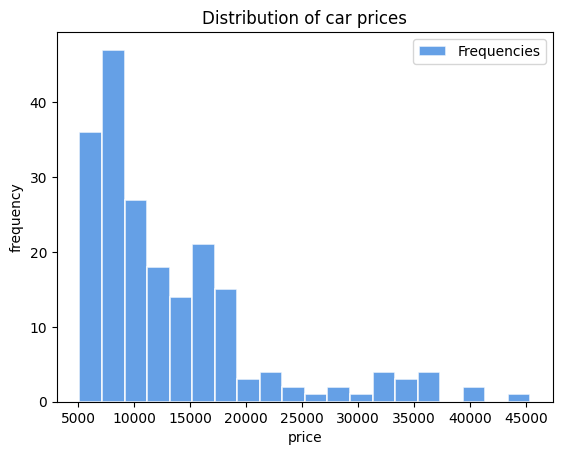

In [ ]:
# Distribution of prices
plt.hist(df['price'], bins=20, color='#4a90e2',
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85,
    label='Frequencies')
plt.xlabel('price')
plt.ylabel('frequency')
plt.title('Distribution of car prices')
plt.legend()
plt.show()

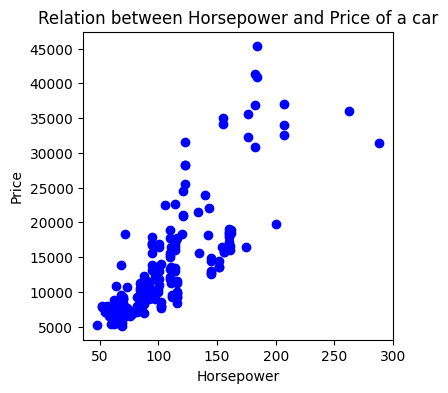

In [ ]:
plt.figure(figsize=(4,4))
# Relation between horse power and price
plt.scatter(df['horsepower'],df['price'],c='blue')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Relation between Horsepower and Price of a car')
plt.show()

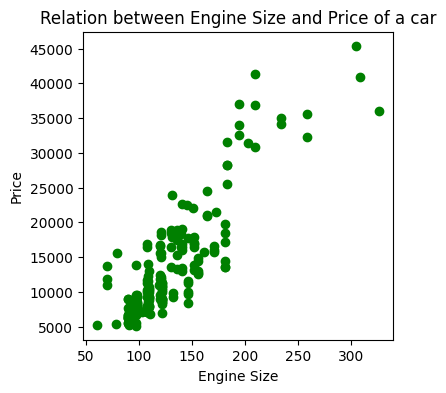

In [ ]:
plt.figure(figsize=(4,4))
#Relation between enginesize and price
plt.scatter(df['enginesize'],df['price'], c= 'green')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.title('Relation between Engine Size and Price of a car')
plt.show()

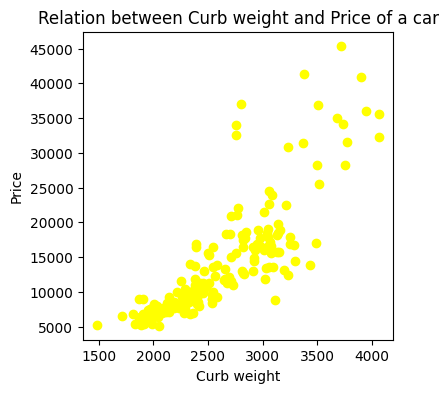

In [ ]:
plt.figure(figsize=(4,4))
#Relation between curbweight and price
plt.scatter(df['curbweight'],df['price'], c = 'yellow')
plt.xlabel('Curb weight')
plt.ylabel('Price')
plt.title('Relation between Curb weight and Price of a car')
plt.show()

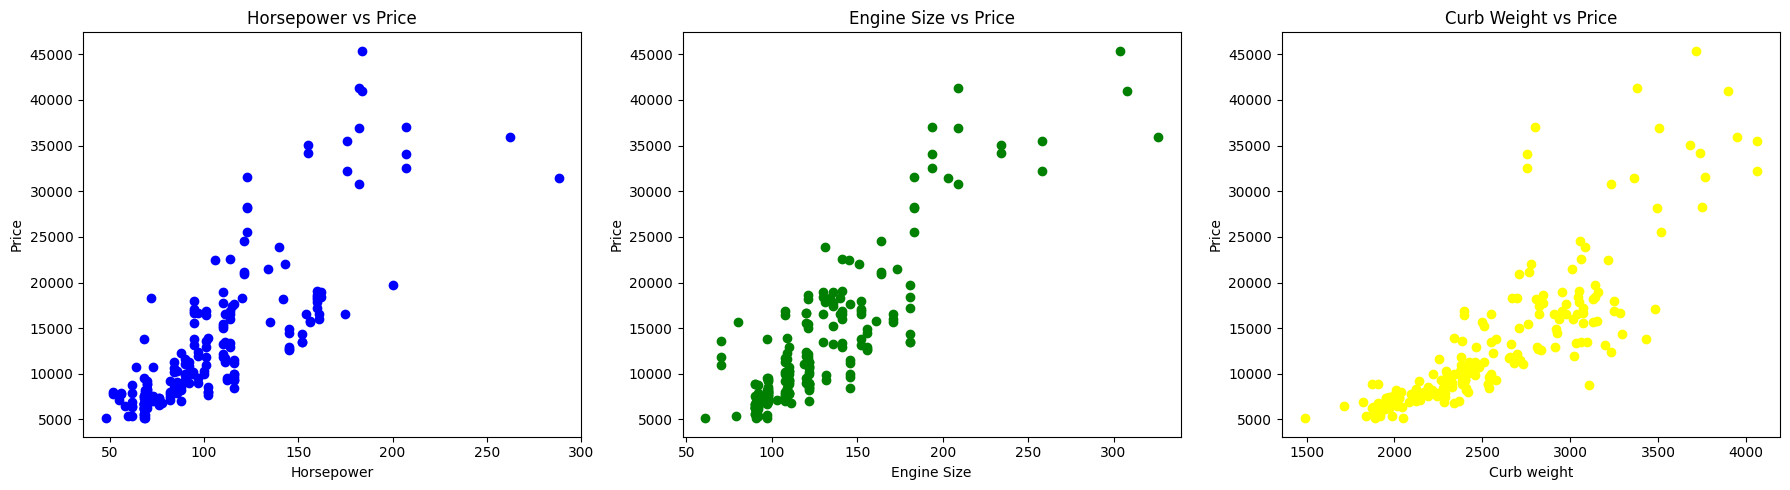

In [ ]:
# Create a grid of 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Horsepower
axes[0].scatter(df['horsepower'], df['price'], c='blue')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Price')
axes[0].set_title('Horsepower vs Price')

# Plot 2: Engine Size
axes[1].scatter(df['enginesize'], df['price'], c='green')
axes[1].set_xlabel('Engine Size')
axes[1].set_ylabel('Price')
axes[1].set_title('Engine Size vs Price')

# Plot 3: Curb Weight
axes[2].scatter(df['curbweight'], df['price'], c='yellow')
axes[2].set_xlabel('Curb weight')
axes[2].set_ylabel('Price')
axes[2].set_title('Curb Weight vs Price')

plt.tight_layout() # Prevents labels from overlapping
plt.show()


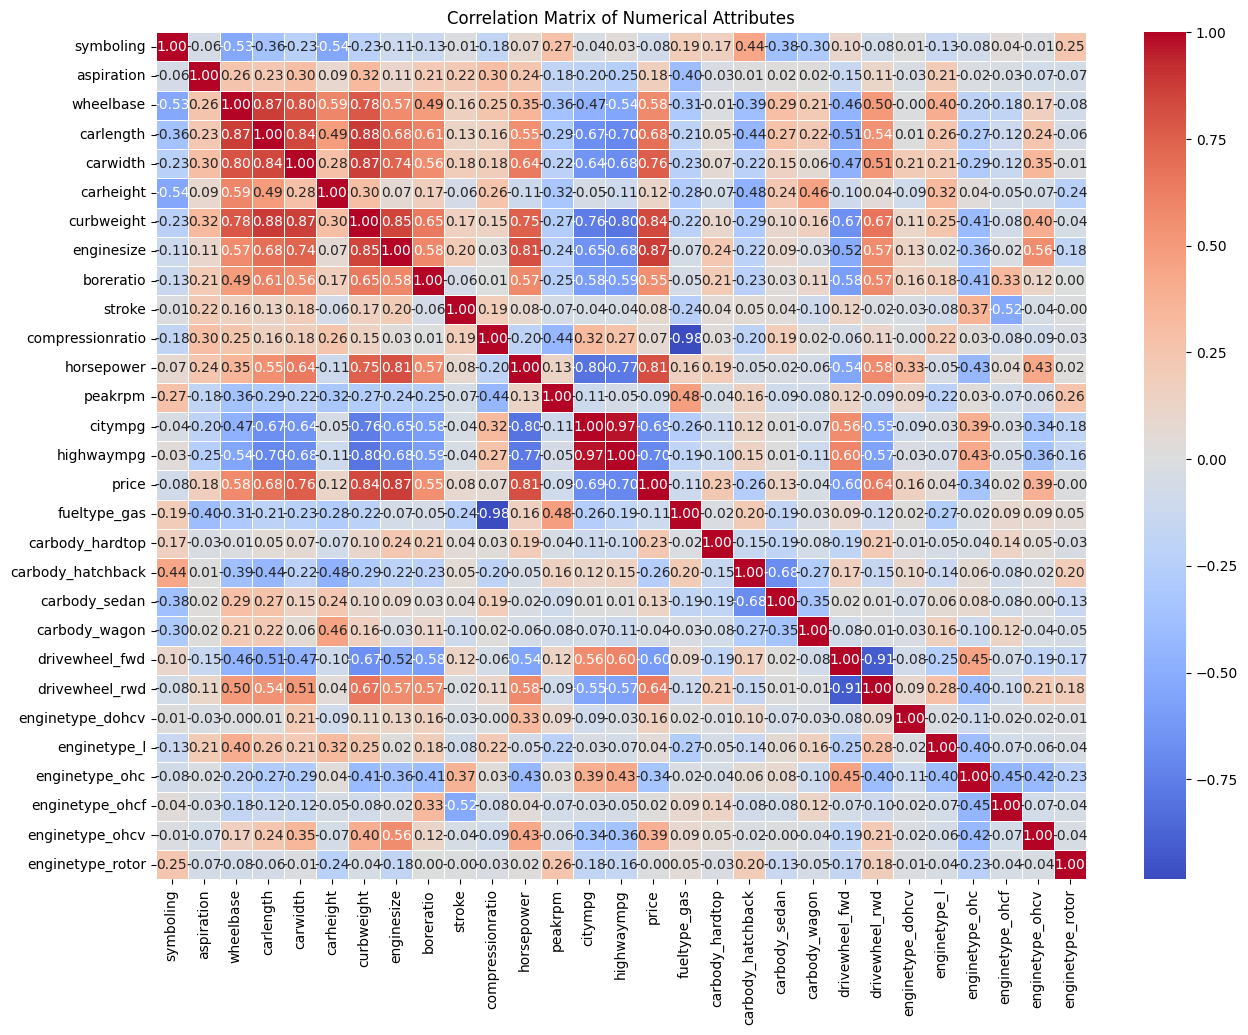

In [ ]:
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 11))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Attributes')
plt.show()


From the correlation heatmap, you can observe the strength and direction of the linear relationship between each pair of numerical variables. Pay close attention to the 'price' row/column to identify which features have the strongest positive or negative correlation with car price. Generally, correlations closer to 1 or -1 indicate a stronger relationship.

## 4. Building Regression Model

In [ ]:
#Splitting the data
XTrain, XTest, yTrain, Ytest = train_test_split(X, y, test_size = 0.2)
#scaling the data
scaler = StandardScaler()
XTrainScaled = scaler.fit_transform(XTrain)
XTestScaled = scaler.transform(XTest)
# Fitting the model
reg = linreg()
reg.fit(XTrainScaled, yTrain)


[-0.6988985   2.20389266 -0.30073949 -0.01151737 -0.20833598  0.49976242
  0.17555233 -0.45224244  1.08610415 -1.96309644 -0.62898974  0.16906566
 -0.64303675 -0.36028385 -1.13314276  0.32879797 -0.22645541 -0.73970927
 -0.9067647   2.68328157 -1.13038833 -0.8        -0.07832604 -0.2409658
 -1.55456318  3.55902608 -0.28097574 -0.13650473]


In [ ]:
reg.score(XTestScaled, Ytest)

0.9105193597909056

In [ ]:
# Making Predictions
TestingData = XTestScaled[6]
print("Testing Data :")
print(TestingData)
actualValue = Ytest.iloc[6]
print(f"Actual Value(Price) : {actualValue}")
PredictedValue = reg.predict([TestingData])
print(f"Predicted Result (Predicted Price): {PredictedValue}")

Testing Data :
[ 1.7749005   2.20389266 -0.46970583 -0.04436691  0.21875278 -1.42632195
  0.68526994  0.64147568  0.97452277  1.94843407 -0.80631353  1.00480158
 -0.22579431 -0.9616737  -0.99084918  0.32879797 -0.22645541  1.35188247
 -0.9067647  -0.372678    0.88465174 -0.8        -0.07832604 -0.2409658
  0.64326752 -0.28097574 -0.28097574 -0.13650473]
Actual Value(Price) : 14869.0
Predicted Result (Predicted Price): [14449.70485751]


## 5. Evaluating the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the entire test set
Ypred = reg.predict(XTestScaled)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(Ytest, Ypred)
print(f'Mean Absolute Error (MAE): {mae:.2f}')

#Mean Squared Error
mse = mean_squared_error(Ytest, Ypred)
print(f'Mean Squareed Error (MSE): {mse:.2f}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(Ytest, Ypred))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

#R squared
Rsquared = reg.score(XTestScaled, Ytest)
print(f'R squared : {Rsquared}')


Mean Absolute Error (MAE): 1653.09
Mean Squareed Error (MSE): 4632978.52
Root Mean Squared Error (RMSE): 2152.44
R squared : 0.9105193597909056


## 6. Visualizations and Prediction

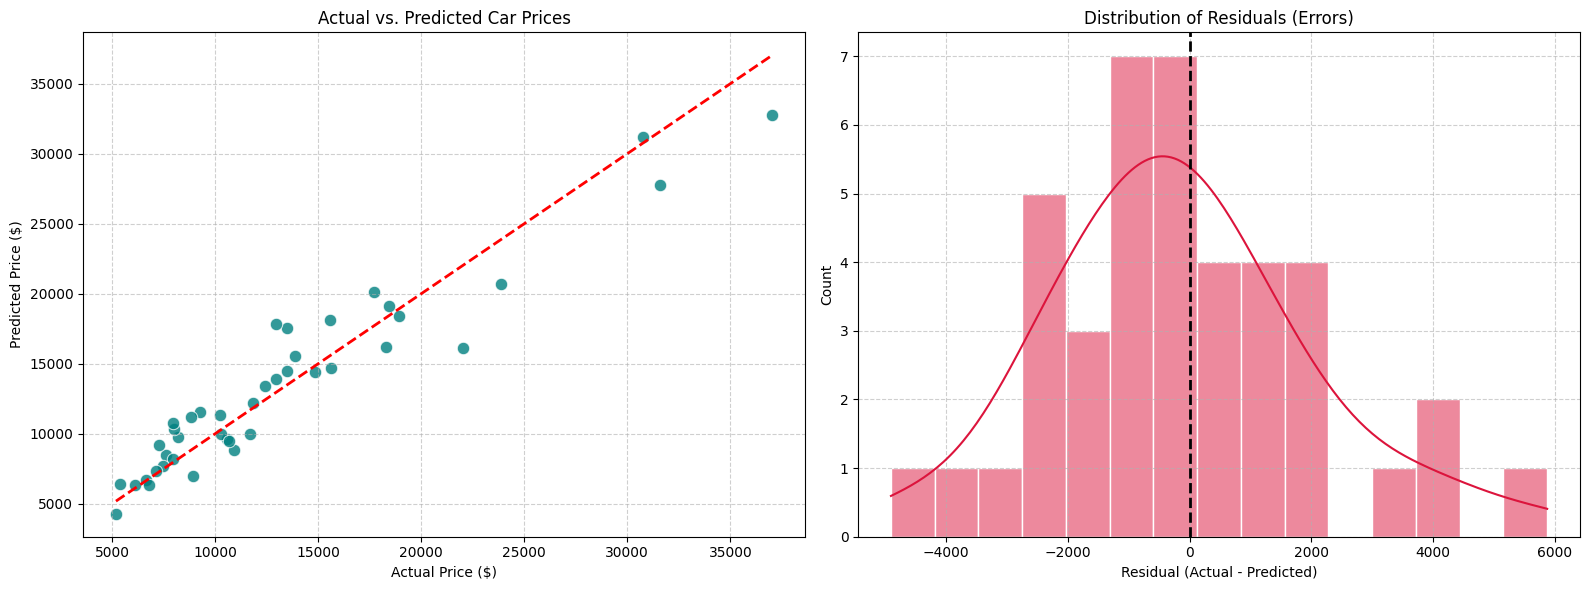

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = Ytest - Ypred

# Create a figure for evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted Prices
sns.scatterplot(x=Ytest, y=Ypred, ax=axes[0], color='teal', alpha=0.8, edgecolor='w', s=80)
axes[0].plot([Ytest.min(), Ytest.max()], [Ytest.min(), Ytest.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs. Predicted Car Prices')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='crimson', bins=15, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals (Errors)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Model Performance Interpretation

Based on our linear regression model metrics and plots:

1. **R-squared ($R^2$) of ~0.91**:
   * This suggests that approximately **91% of the variance** in car prices can be explained by our selected independent features (such as engine size, horsepower, curb weight, etc.). This indicates a highly predictive and strong linear relationship.

2. **Mean Absolute Error (MAE) of ~1,653.09**:
   * On average, our model's predictions deviate from the actual car prices by about **$1,653**. Given that car prices in this dataset range from $5,118 to $45,400, this average error is relatively small and acceptable.

3. **Root Mean Squared Error (RMSE) of ~2,152.44**:
   * The RMSE penalizes larger prediction errors more heavily than MAE. The fact that the RMSE ($2,152.44) is slightly higher than the MAE ($1,653.09) reveals that we have some larger errors (outliers), which is also apparent in our scatter and residual plots.

4. **Actual vs. Predicted Plot Analysis**:
   * The points are clustered closely along the red diagonal identity line ($y = x$), showing that our predictions are highly accurate across most price ranges. However, accuracy decreases slightly for luxury cars with prices above $30,000.

5. **Residuals Distribution Analysis**:
   * The residuals are centered around $0$, indicating that our model does not have a systemic bias (underestimating or overestimating consistently). The distribution resembles a normal curve, validating our assumption of normally distributed errors.

The Mean Absolute Error (MAE) tells you the average magnitude of errors in a set of predictions, without considering their direction. The Root Mean Squared Error (RMSE) is the square root of the average of the squared errors, giving more weight to larger errors. These metrics provide a more robust understanding of your model's predictive accuracy across all test data points, rather than focusing on a single, potentially anomalous prediction.

## 7. Prediction of New Car

In [53]:
import numpy as np
import pandas as pd

# 1. Create a sample car matching the format of X (DataFrame)
# We'll take a copy of an existing row as a baseline to ensure all columns exist
sample_car = X.iloc[[0]].copy()

# 2. Modify attributes of our customized sample car
sample_car['symboling'] = 1
sample_car['aspiration'] = 1.0  # turbo
sample_car['wheelbase'] = 100.0
sample_car['carlength'] = 175.0
sample_car['carwidth'] = 66.0
sample_car['carheight'] = 54.0
sample_car['curbweight'] = 2800.0
sample_car['enginesize'] = 140.0
sample_car['boreratio'] = 3.5
sample_car['stroke'] = 3.15
sample_car['compressionratio'] = 9.0
sample_car['horsepower'] = 150.0
sample_car['peakrpm'] = 5500.0
sample_car['citympg'] = 22.0
sample_car['highwaympg'] = 28.0

# 3. Apply the fitted scaler to our sample features
sample_car_scaled = scaler.transform(sample_car)

# 4. Predict the selling price
predicted_price = reg.predict(sample_car_scaled)[0]

# Display the custom car details and the predicted price
print("=== Customized Sample Car Attributes ===")
for col in ['enginesize', 'horsepower', 'curbweight', 'citympg', 'highwaympg']:
    print(f"{col}: {sample_car[col].values[0]}")

print(f"\nPredicted Selling Price: ${predicted_price:,.2f}")

=== Customized Sample Car Attributes ===
enginesize: 140.0
horsepower: 150.0
curbweight: 2800.0
citympg: 22.0
highwaympg: 28.0

Predicted Selling Price: $21,280.85
